In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from Scripts_Imane import Format_Data

/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:6: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data_path = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-03-25.csv')


## zscore

In [4]:
# import pandas as pd
# import numpy as np

# # Load your data
# data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')

# # Filter wild types
# wt_df = data[data['mutated_genes'].str.startswith('WT')]

# # Compute global WT mean and std per regime
# wt_stats = wt_df.groupby('light_regime')['y2_slope'].agg(['mean', 'std']).reset_index()
# wt_stats = wt_stats.rename(columns={'mean': 'WT_mean', 'std': 'WT_std'})

# # Merge these stats back into the main dataset
# data = data.merge(wt_stats, on='light_regime', how='left')

# # Compute z-score for each mutant (or WT, if you want them too)
# data['z_score'] = (data['y2_slope'] - data['WT_mean']) / data['WT_std']

# # Save results
# data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/mutants_with_global_WT_zscores.csv', index=False)

# print(data[['mutant_ID', 'mutated_genes', 'light_regime', 'y2_slope', 'z_score']].head())

import pandas as pd
import numpy as np

# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')

# Filter wild types
wt_df = data[data['mutated_genes'].str.startswith('WT')]

# Compute WT stats per regime
wt_stats = wt_df.groupby('light_regime')['y2_slope'].agg(['mean', 'std']).reset_index()
wt_stats = wt_stats.rename(columns={'mean': 'WT_mean', 'std': 'WT_std'})

# Compute mean slope for each mutant_ID (averaging its replicates/wells)
mutant_means = data.groupby(['mutant_ID', 'mutated_genes', 'light_regime'])['y2_slope'].mean().reset_index()

# Merge WT stats
mutant_means = mutant_means.merge(wt_stats, on='light_regime', how='left')

# Compute z-score
mutant_means['z_score'] = (mutant_means['y2_slope'] - mutant_means['WT_mean']) / mutant_means['WT_std']

# Drop WT rows if you only want mutants
mutant_means = mutant_means[~mutant_means['mutated_genes'].str.startswith('WT')]

# Save results
mutant_means.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/mutant_level_zscores.csv', index=False)

print(mutant_means.head())


           mutant_ID  mutated_genes light_regime  y2_slope   WT_mean  \
0  LMJ.RY0402.038618  Cre17.g708800  10min-10min -0.003318 -0.002158   
1  LMJ.RY0402.038618  Cre17.g708800    1min-1min -0.002455 -0.001454   
2  LMJ.RY0402.038618  Cre17.g708800    1min-5min -0.002059 -0.002028   
3  LMJ.RY0402.038618  Cre17.g708800       20h_HL -0.005469 -0.003809   
4  LMJ.RY0402.038618  Cre17.g708800       20h_ML -0.003024 -0.001820   

     WT_std   z_score  
0  0.000662 -1.752652  
1  0.000643 -1.556346  
2  0.000455 -0.069110  
3  0.000871 -1.907442  
4  0.000565 -2.130970  


## Sparse CCA

use the z-scores maybe instead of theplots

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sparsecca import cca_pmd

K = 8       
penalty_x = 0.3
penalty_y = 0.3

df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/mutant_level_zscores.csv')
df = df[~(df['mutant_ID']== 'WT')]  #
#df = df[~(df['light_regime'].isin(['20h_ML','10min-10min']))]  #

df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]

# Gene presence/absence matrix
df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
                   values='presence', fill_value=0)

# Phenotype matrix
Y = df.pivot_table(index='mutant_ID', columns='light_regime',
                   values='z_score', aggfunc='mean')

common = X.index.intersection(Y.index)
X, Y = X.loc[common], Y.loc[common]

Y = Y.fillna(Y.mean())
Y = Y.clip(lower=-1e6, upper=1e6)

X = X.loc[:, X.var() > 0]

X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
X_scaled = X_scaled[mask]
Y_scaled = Y_scaled[mask]

print("Cleaned X:", X_scaled.shape, "Cleaned Y:", Y_scaled.shape)

U, V, D = cca_pmd(
    X_scaled, Y_scaled,
    penaltyx=penalty_x,
    penaltyz=penalty_y,
    K=K,
    standardize=False
)


results = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]

    important_genes = X.columns[(abs(U[:, k]) > 1e-4)]
    important_phenos = Y.columns[(abs(V[:, k]) > 1e-4)]

    results.append({
        "component": k+1,
        "correlation": corr_k,
        "genes": list(important_genes),
        "phenotypes": list(important_phenos)
    })

for res in results:
    print(f"\n=== Canonical Component {res['component']} ===")
    print(f"Correlation: {res['correlation']:.3f}")
    print("Correlated genes:", res['genes'][:15], "..." if len(res['genes']) > 15 else "")
    print("Correlated light regimes:", res['phenotypes'])


genes_used = X.columns
phenos_used = Y.columns

records = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]

    for gene_idx, gene in enumerate(genes_used):
        if abs(U[gene_idx, k]) > 1e-4:
            for pheno_idx, pheno in enumerate(phenos_used):
                if abs(V[pheno_idx, k]) > 1e-4:
                    records.append({
                        "component": k+1,
                        "correlation": corr_k,
                        "gene": gene,
                        "gene_weight": abs(U[gene_idx, k]),
                        "light_regime": pheno,
                        "pheno_weight": abs(V[pheno_idx, k])
                    })

results_df = pd.DataFrame(records)
results_df.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv",
    index=False
)

Cleaned X: (1082, 564) Cleaned Y: (1082, 8)

=== Canonical Component 1 ===
Correlation: 0.658
Correlated genes: ['Cre01.g008200', 'Cre01.g012150', 'Cre01.g012650,Cre17.g724450', 'Cre01.g015200', 'Cre01.g015200,Cre12.g503500', 'Cre01.g016556,Cre07.g352250', 'Cre01.g017200,Cre12.g554400', 'Cre01.g018700', 'Cre01.g019550', 'Cre01.g019750', 'Cre01.g019850', 'Cre01.g024800,Cre01.g040250', 'Cre01.g024800,Cre13.g580150', 'Cre01.g025400', 'Cre01.g025400,Cre01.g025450 & Cre01.g025500'] ...
Correlated light regimes: ['30s-30s']

=== Canonical Component 2 ===
Correlation: 0.542
Correlated genes: ['Cre01.g012150', 'Cre01.g016556,Cre07.g352250', 'Cre01.g017200,Cre12.g554400', 'Cre01.g022650,Cre16.g676869', 'Cre01.g025400', 'Cre01.g038151', 'Cre01.g039550', 'Cre01.g040250', 'Cre02.g089237', 'Cre02.g090100', 'Cre02.g093300,Cre16.g685451', 'Cre02.g095081', 'Cre02.g095115,Cre13.g565150', 'Cre02.g103400', 'Cre02.g106650'] ...
Correlated light regimes: ['20h_ML']

=== Canonical Component 3 ===
Correlatio

In [9]:
results_df.head()

,component,correlation,gene,gene_weight,light_regime,pheno_weight
0,1,0.658288,Cre01.g008200,0.006323,30s-30s,1.0
1,1,0.658288,Cre01.g012150,0.137190,30s-30s,1.0
2,1,0.658288,"Cre01.g012650,Cre17.g724450",0.174175,30s-30s,1.0
3,1,0.658288,Cre01.g015200,0.007912,30s-30s,1.0
4,1,0.658288,"Cre01.g015200,Cre12.g503500",0.007886,30s-30s,1.0


## most signif genes

In [10]:
list_fl = results_df[((results_df['light_regime']=='20h_HL') & (results_df['gene_weight']>0.2))]['gene']

print(list(list_fl))

['Cre02.g095115,Cre13.g565150', 'Cre03.g176961,Cre14.g613652', 'Cre04.g213652', 'Cre04.g215800', 'Cre04.g229163,Cre09.g393000', 'Cre08.g367350', 'Cre12.g554100']


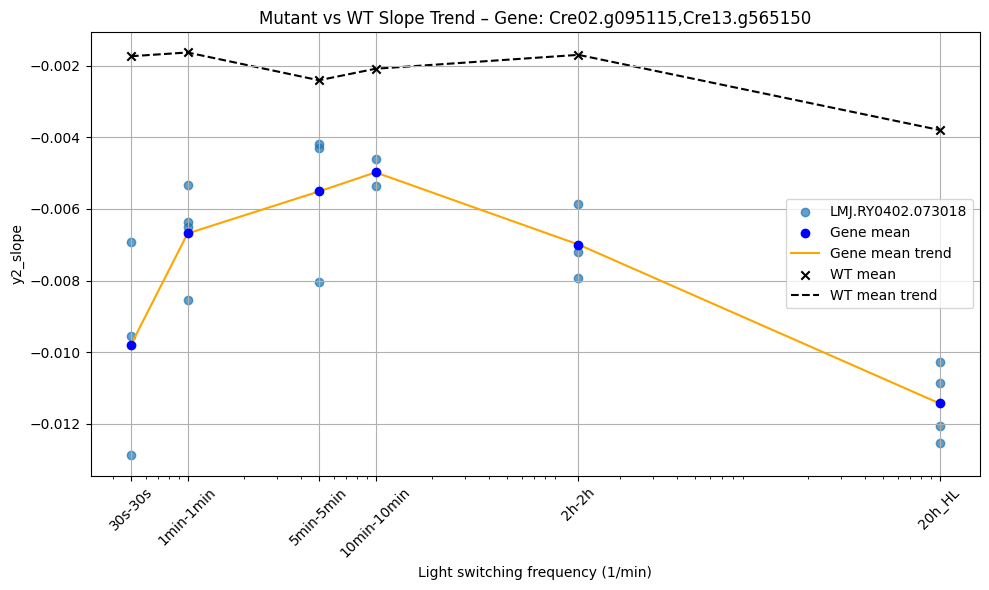

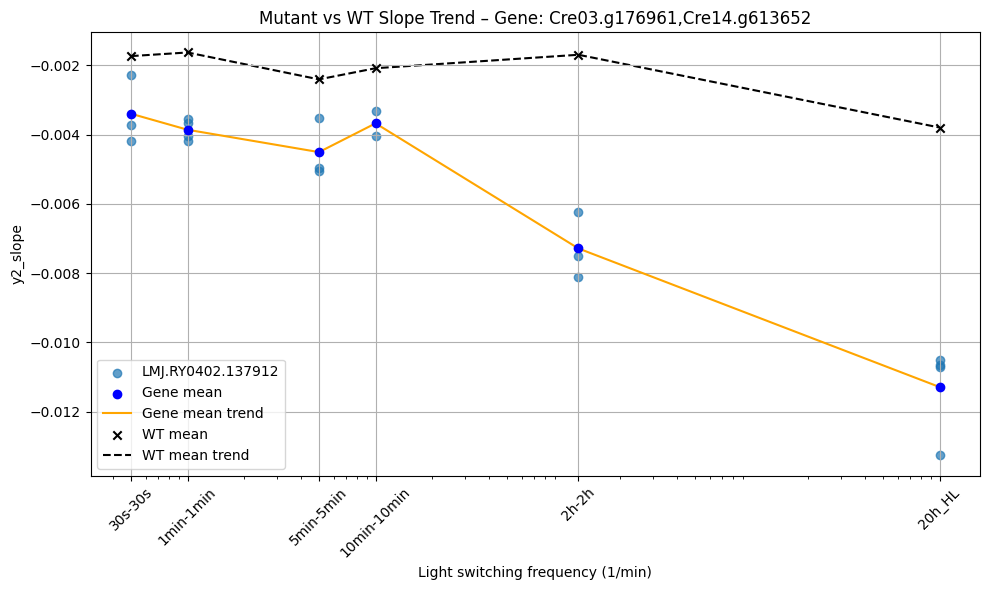

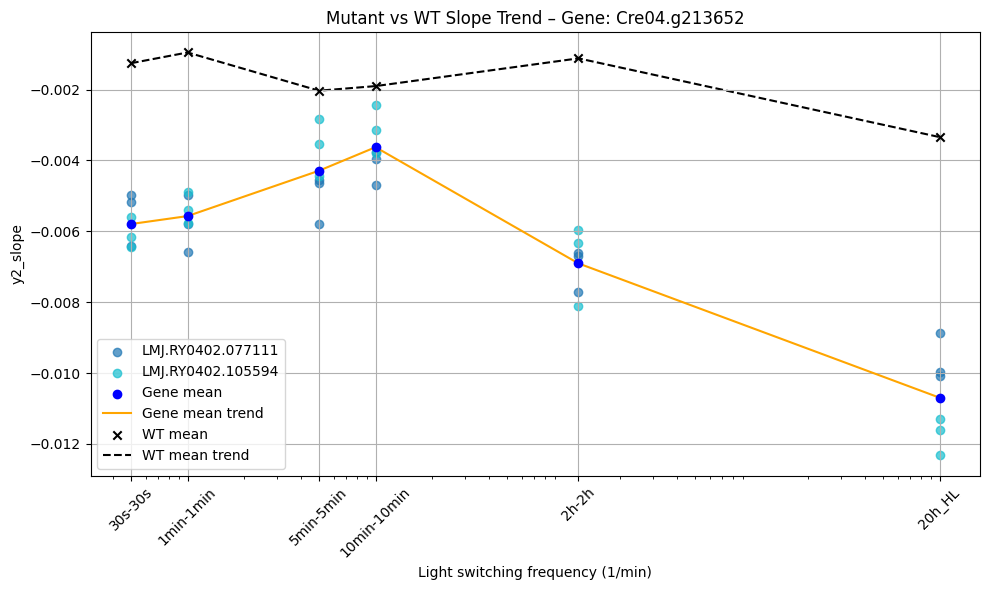

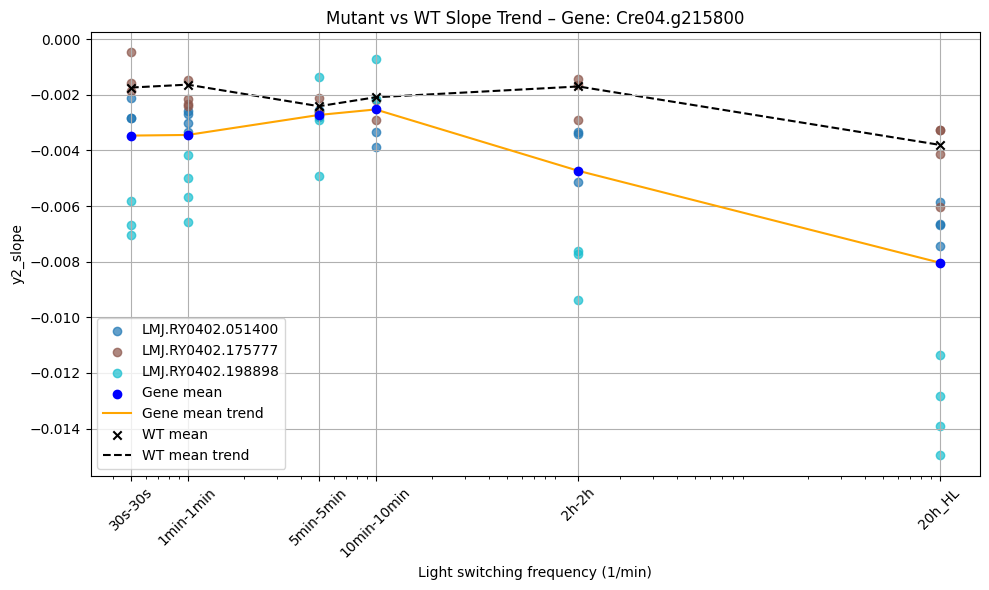

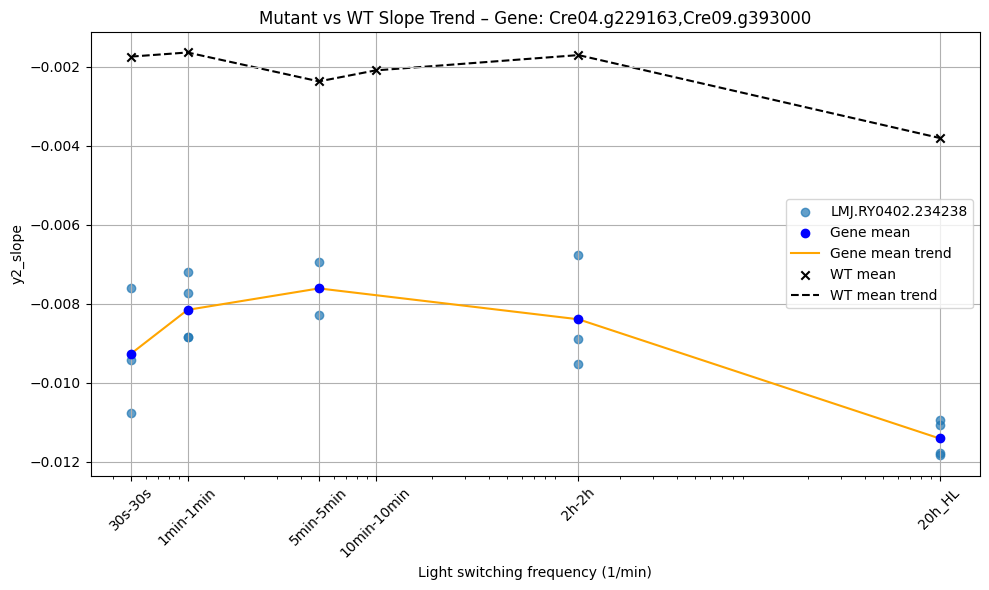

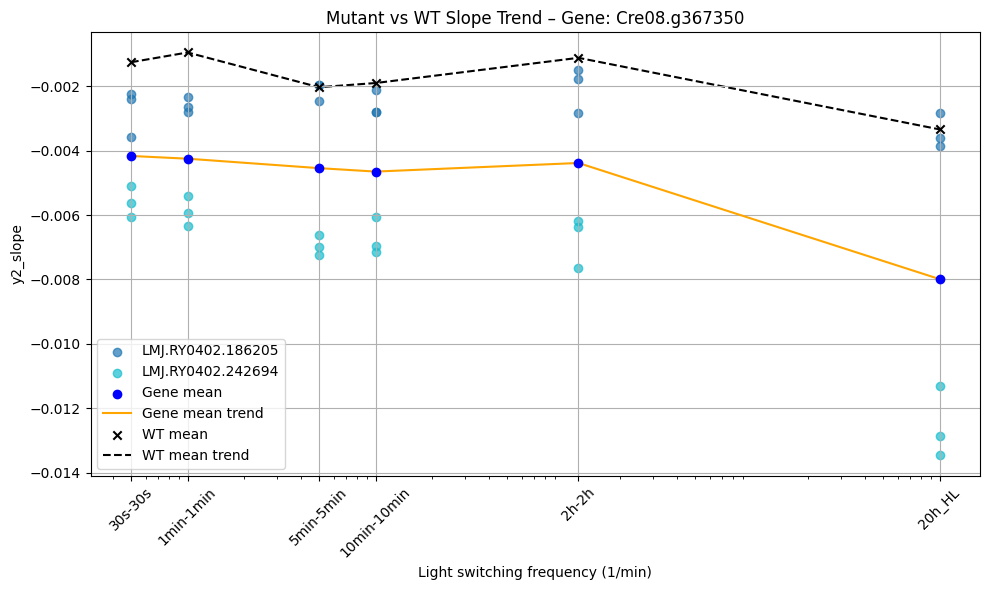

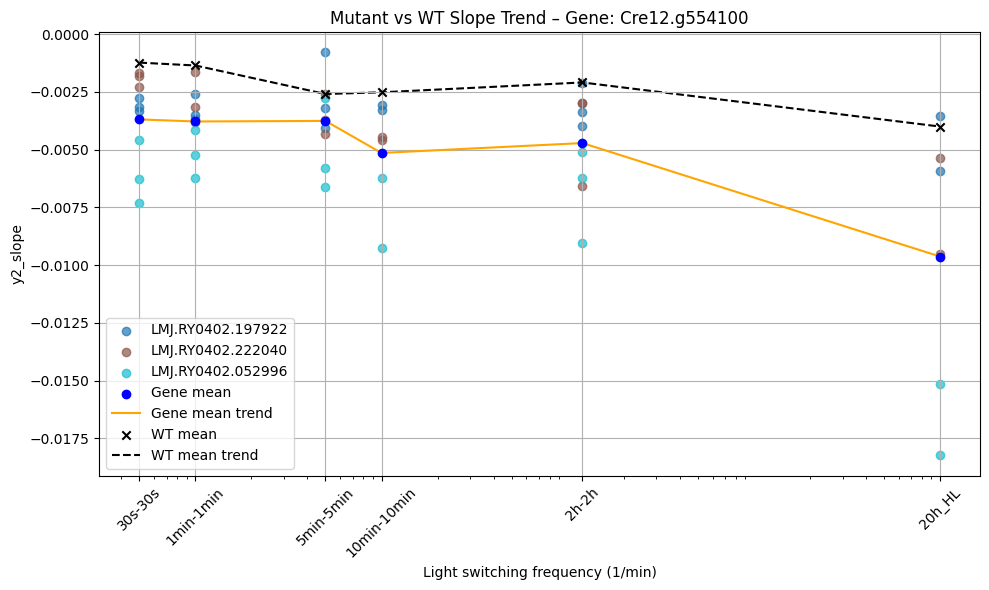

In [11]:
from Scripts_Imane import Plots
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
Plots.plot_slope_lights_trend_log(data, list_fl)

In [26]:
genes_to_flag = [
    'Cre12.g531900', 'Cre16.g661200', 'Cre07.g314800',
    'Cre13.g588150', 'Cre06.g278110', 'Cre05.g235800',
    'Cre02.g105350', 'Cre13.g581900', 'Cre07.g323450',
    'Cre15.g635800'
]

# === Flagged gene analysis ===
flagged_hits = results_df[results_df['gene'].isin(genes_to_flag)].copy()
found_genes = set(flagged_hits['gene'])
missing_genes = set(genes_to_flag) - found_genes

print("=== Flagged Genes Found in CCA ===")
print(flagged_hits[['component','light_regime','gene','gene_weight','pheno_weight']].sort_values(['gene','component']))

print("\n=== Flagged Genes Missing from CCA ===")
print(missing_genes if missing_genes else "None — all flagged genes found!")

flagged_hits.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/flagged_genes_in_cca_with_weights.csv",
    index=False
)

=== Flagged Genes Found in CCA ===
      component light_regime           gene  gene_weight  pheno_weight
314           3  10min-10min  Cre05.g235800     0.031163           1.0
74            1      30s-30s  Cre07.g314800     0.011717           1.0
596           5    1min-5min  Cre07.g314800     0.018812           1.0
988           8    1min-1min  Cre07.g314800     0.021432           1.0
78            1      30s-30s  Cre07.g323450     0.066813           1.0
211           2       20h_ML  Cre07.g323450     0.002835           1.0
330           3  10min-10min  Cre07.g323450     0.032130           1.0
477           4       20h_HL  Cre07.g323450     0.078003           1.0
599           5    1min-5min  Cre07.g323450     0.059157           1.0
733           6    5min-5min  Cre07.g323450     0.017719           1.0
864           7        2h-2h  Cre07.g323450     0.062301           1.0
990           8    1min-1min  Cre07.g323450     0.093462           1.0
138           1      30s-30s  Cre12.g53190

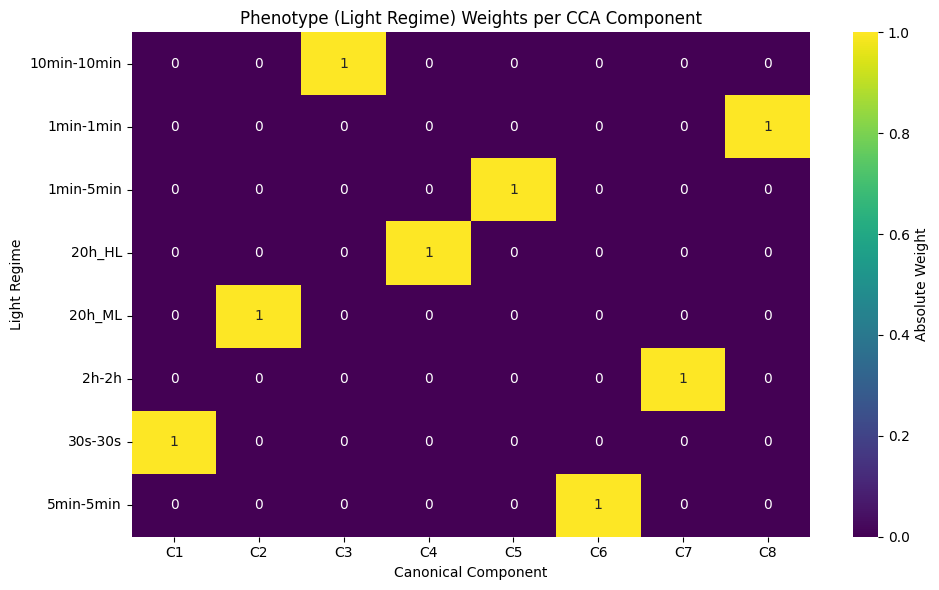

KeyError: "['Cre06.g278110', 'Cre13.g581900'] not in index"

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Build DataFrame of phenotype weights
pheno_weights_df = pd.DataFrame(V, index=Y.columns, columns=[f"C{k+1}" for k in range(V.shape[1])])

plt.figure(figsize=(10,6))
sns.heatmap(pheno_weights_df.abs(), annot=True, cmap="viridis", cbar_kws={'label': 'Absolute Weight'})
plt.title("Phenotype (Light Regime) Weights per CCA Component")
plt.xlabel("Canonical Component")
plt.ylabel("Light Regime")
plt.tight_layout()
plt.show()
# Build DataFrame for gene weights (filtered)
gene_weights_df = pd.DataFrame(U, index=X.columns, columns=[f"C{k+1}" for k in range(U.shape[1])])
gene_weights_filtered = gene_weights_df.loc[genes_to_flag]

plt.figure(figsize=(10,6))
sns.heatmap(gene_weights_filtered.abs(), annot=True, cmap="magma", cbar_kws={'label': 'Absolute Weight'})
plt.title("Flagged Gene Weights per CCA Component")
plt.xlabel("Canonical Component")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


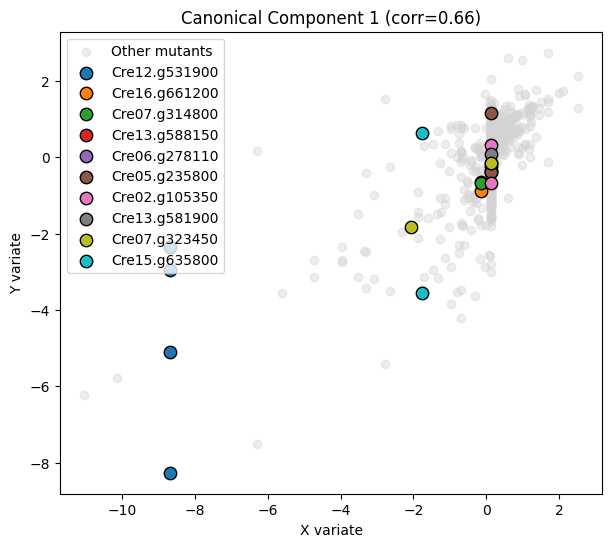

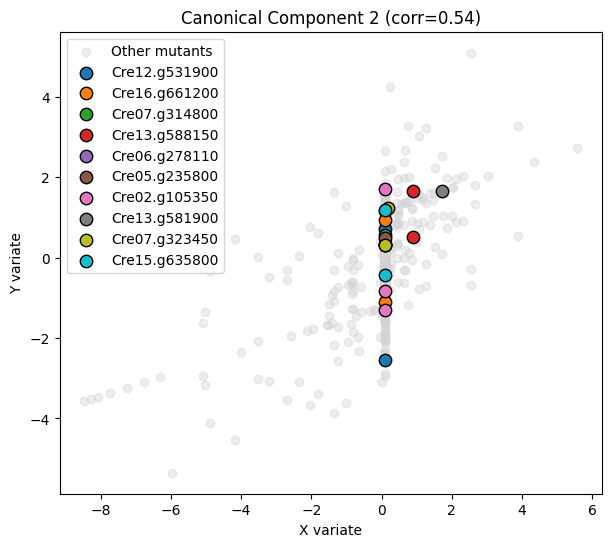

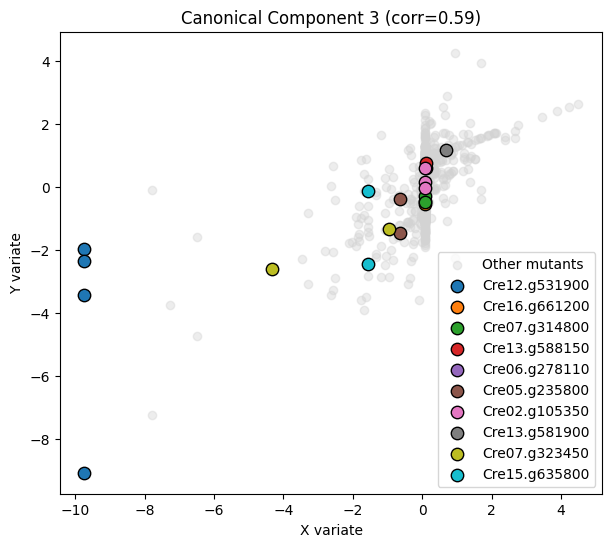

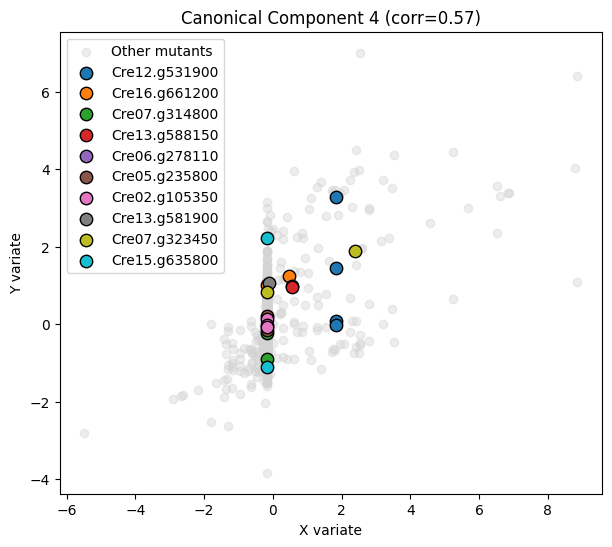

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Genes you want to highlight
genes_to_flag = ['Cre12.g531900',
'Cre16.g661200',
'Cre07.g314800',
'Cre13.g588150',
'Cre06.g278110',
'Cre05.g235800',
'Cre02.g105350',
'Cre13.g581900',
'Cre07.g323450','Cre15.g635800']
# Mutant_ID → genes mapping (aggregate multiple hits)
mutant_gene_map = df.groupby('mutant_ID')['mutated_genes'] \
                      .apply(lambda x: ','.join(set(x))).to_dict()

# Ensure X and Y are aligned and reset index to keep track
X = X.reset_index()
Y = Y.reset_index()
mutant_ids = X['mutant_ID']  # keep mutant IDs safe

# Standardize
X_scaled = StandardScaler().fit_transform(X.drop(columns='mutant_ID'))
Y_scaled = StandardScaler().fit_transform(Y.drop(columns='mutant_ID'))

# Drop bad rows after scaling
mask_X = np.isfinite(X_scaled).all(axis=1)
mask_Y = np.isfinite(Y_scaled).all(axis=1)
valid_mask = mask_X & mask_Y

X_scaled = X_scaled[valid_mask]
Y_scaled = Y_scaled[valid_mask]
valid_mutant_ids = mutant_ids[valid_mask].values

for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]

    scatter_df = pd.DataFrame({
        'mutant_ID': valid_mutant_ids,
        'X_c': X_ck,
        'Y_c': Y_ck
    })
    scatter_df['mutated_genes'] = scatter_df['mutant_ID'].map(mutant_gene_map)

    plt.figure(figsize=(7,6))
    plt.scatter(scatter_df['X_c'], scatter_df['Y_c'],
                color='lightgray', alpha=0.4, label='Other mutants')

    colors = plt.cm.tab10(np.linspace(0, 1, len(genes_to_flag)))
    gene_color_map = {gene: colors[i] for i, gene in enumerate(genes_to_flag)}

    for gene, color in gene_color_map.items():
        mask = scatter_df['mutated_genes'].astype(str).str.contains(gene, na=False)
        plt.scatter(scatter_df.loc[mask, 'X_c'],
                    scatter_df.loc[mask, 'Y_c'],
                    color=color, edgecolor='black', s=80, label=gene)

    plt.title(f"Canonical Component {k+1} (corr={np.corrcoef(X_ck, Y_ck)[0,1]:.2f})")
    plt.xlabel("X variate")
    plt.ylabel("Y variate")
    plt.legend()
    plt.show()


Top contributing genes (comp 1): Index(['Cre12.g531900', 'Cre02.g095115,Cre13.g565150',
       'Cre04.g229163,Cre09.g393000', 'Cre05.g248250', 'Cre04.g213652',
       'Cre16.g648750', 'Cre08.g358571', 'Cre01.g012650,Cre17.g724450',
       'Cre09.g386850', 'Cre01.g012150'],
      dtype='object', name='mutated_genes')


/tmp/ipykernel_582908/2485432963.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


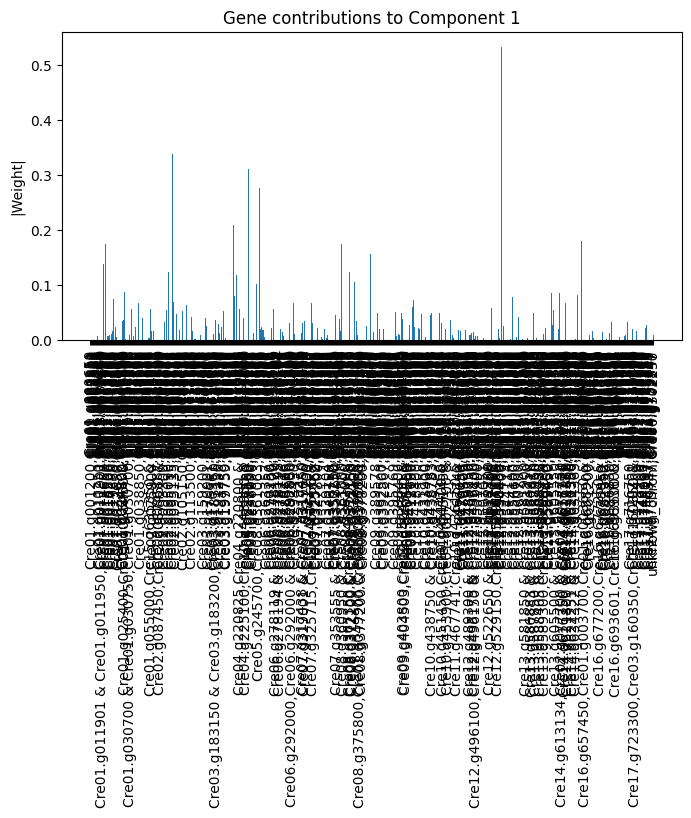

In [22]:
top_genes_c1 = X.columns[np.argsort(abs(U[:,0]))[::-1][:10]]
print("Top contributing genes (comp 1):", top_genes_c1)

plt.figure(figsize=(8,4))
plt.bar(X.columns, np.abs(U[:,0]))
plt.title("Gene contributions to Component 1")
plt.ylabel("|Weight|")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


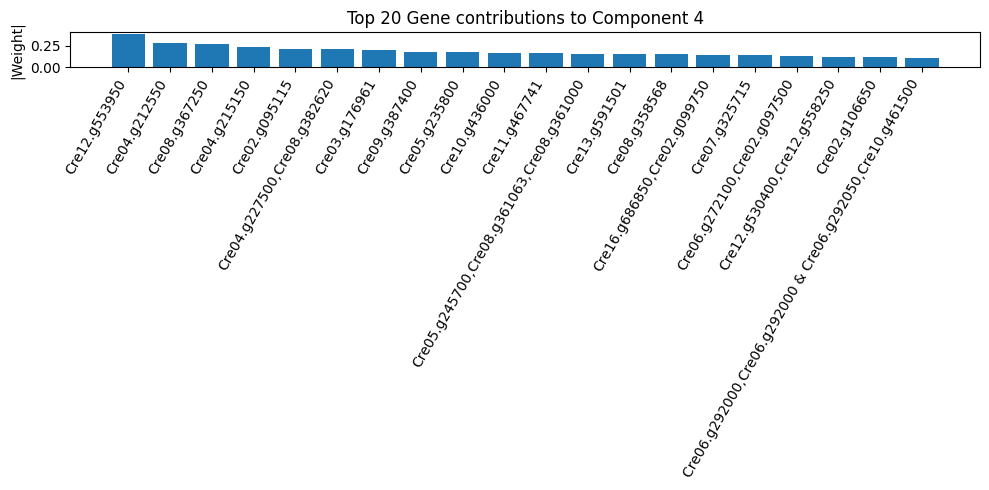

In [17]:
import matplotlib.pyplot as plt
import numpy as np

k = 3  # component index (0 = Component 1)
N = 20 # how many top genes to show

weights = np.abs(U[:,k])
top_idx = np.argsort(weights)[::-1][:N]

plt.figure(figsize=(10,5))
plt.bar(np.array(X.columns)[top_idx], weights[top_idx])
plt.title(f"Top {N} Gene contributions to Component {k+1}")
plt.ylabel("|Weight|")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gprofiler import GProfiler
from sklearn.preprocessing import StandardScaler
from sparsecca import cca_pmd

# === Assume you already have X, Y, and ran cca_pmd ===
# U, V, D = cca_pmd(X_scaled, Y_scaled, penaltyx=0.3, penaltyz=0.3, K=4, standardize=False)

# Capture the gene list that matches U
genes_used = X.columns[:U.shape[0]]
print(f"U shape: {U.shape}, Genes used: {len(genes_used)}")

# g:Profiler client
gp = GProfiler(return_dataframe=True)

# Parameters
K = U.shape[1]        # number of canonical components
threshold = 0.1       # weight threshold for gene selection
background_genes = genes_used.tolist()  # background = all tested genes

for k in range(K):
    print(f"\n=== Component {k+1} ===")
    weights = U[:, k]
    
    # Select genes above threshold
    selected_genes = [genes_used[i] for i in range(len(weights)) if abs(weights[i]) > threshold]
    print(f"Selected {len(selected_genes)} genes for enrichment")
    
    # Skip if no genes pass threshold
    if len(selected_genes) == 0:
        print("⚠️ No genes passed threshold; skipping enrichment.")
        continue

    # Save gene list
    pd.Series(selected_genes).to_csv(f"cca_component{k+1}_genes.txt", index=False, header=False)

    # Run GO enrichment
    enrich_results = gp.profile(
        organism='creinhardtii',
        query=selected_genes,
        no_evidences=False,
        user_threshold=0.05,
        sources=['GO:BP', 'GO:MF', 'GO:CC'],
        background=background_genes
    )

    # Handle case where no enrichment found
    if enrich_results.empty:
        print("⚠️ No significant GO terms found.")
        continue

    # Save enrichment results
    enrich_results.to_csv(f"cca_component{k+1}_GO_enrichment.csv", index=False)

    # Plot top 15 terms
    sig = enrich_results[enrich_results['p_value'] < 0.05].head(15)
    if not sig.empty:
        plt.figure(figsize=(8,6))
        plt.barh(sig['name'], -np.log10(sig['p_value']))
        plt.xlabel('-log10(p-value)')
        plt.title(f'Top GO enrichment terms (Component {k+1})')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No GO terms below p<0.05 to plot.")


U shape: (564, 4), Genes used: 564

=== Component 1 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 2 ===
Selected 23 genes for enrichment
⚠️ No significant GO terms found.

=== Component 3 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 4 ===
Selected 17 genes for enrichment
⚠️ No significant GO terms found.


In [12]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# Create PDF
with PdfPages('my_report.pdf') as pdf:
    for i in range(3):  # example: 3 plots
        # Generate a plot
        x = np.linspace(0, 10, 100)
        y = np.sin(x + i)
        plt.figure()
        plt.plot(x, y)
        plt.title(f"Plot {i+1}")

        # Add text directly on the figure
        plt.figtext(0.1, 0.01, f"Extra info for plot {i+1}", fontsize=10)

        pdf.savefig()   # saves the current figure
        plt.close()

    # Add a final page with only text
    fig = plt.figure()
    fig.text(0.1, 0.5, "This is some summary text.\nYou can add more details here.", fontsize=12)
    pdf.savefig(fig)
    plt.close(fig)
